# Explore: local RAG with pgvector

Interactive playground on top of this project's own modules (`config.py`, `embeddings.py`, `search.py`, `db.py`, `chunking.py`). Nothing here is required to run `ingest.py` / `search.py` / `rag.py` from the CLI — this notebook is purely for poking around.

Prerequisites: `docker compose up -d` (pgvector) and `ollama serve` should both be running, and `python ingest.py` should have been run at least once so there's data to query.

Kernel: **RAG pgvector (local)** (registered from this project's `.venv` — select it via Kernel → Change Kernel if it isn't already active).

In [1]:
import json
import urllib.request

import numpy as np
import pandas as pd

import config
from chunking import chunk_text
from db import get_connection
from embeddings import embed, embed_one
from search import search

print(f"DB:        {config.DB_HOST}:{config.DB_PORT}/{config.DB_NAME}")
print(f"Embedding: {config.EMBEDDING_MODEL} ({config.EMBEDDING_DIM} dims)")
print(f"Ollama:    {config.OLLAMA_MODEL}")

DB:        localhost:5433/rag
Embedding: qwen3-embedding:0.6b (1024 dims)
Ollama:    llama3.1:8b


## 1. Embeddings

Embed a few sentences and confirm the shape matches `config.EMBEDDING_DIM`.

In [3]:
samples = [
    "Cosine similarity measures the angle between two vectors.",
    "HNSW is a graph-based approximate nearest neighbor algorithm.",
    "I enjoy baking sourdough bread on weekends.",
]
vectors = np.array(embed(samples))
print(vectors.shape)

# pairwise cosine similarity between the three samples above
norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
pd.DataFrame(norm @ norm.T, index=samples, columns=[s[:20] + "..." for s in samples])

(3, 1024)


,Cosine similarity me...,HNSW is a graph-base...,I enjoy baking sourd...
Cosine similarity measures the angle between two vectors.,1.000000,0.546741,0.233893
HNSW is a graph-based approximate nearest neighbor algorithm.,0.546741,1.000000,0.329142
I enjoy baking sourdough bread on weekends.,0.233893,0.329142,1.000000


## 2. Similarity search against the ingested corpus

Uses `search.search()` exactly as `search.py` and `rag.py` do — same pgvector `<=>` query.

In [4]:
query = "What is cosine similarity?"
results = search(query, top_k=5)
pd.DataFrame(results)[["similarity", "source", "chunk_index", "content"]]

,similarity,source,chunk_index,content
0,0.816109,02_similarity_metrics.md,0,# Similarity Metrics The three most common way...
1,0.673197,01_vector_search.md,0,# Vector Search Vector search retrieves items ...
2,0.533527,03_rag_pipeline.md,0,# RAG Pipeline Retrieval-Augmented Generation ...


## 3. Compare embedding models

`ollama list` shows both `qwen3-embedding:0.6b` (this project's default, 1024-dim) and `qwen3-embedding:4b` available locally. Compare how each ranks the same corpus for the same query — useful for deciding whether the larger model is worth the extra latency/memory for your use case.

This calls Ollama directly (bypassing `config.EMBEDDING_MODEL`) so it works regardless of which model the pgvector index was actually built with.

In [5]:
def ollama_embed(texts: list[str], model: str) -> np.ndarray:
    payload = {"model": model, "input": texts}
    request = urllib.request.Request(
        config.OLLAMA_EMBED_URL,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(request, timeout=120) as response:
        body = json.loads(response.read().decode("utf-8"))
    return np.array(body["embeddings"])


def rank_with_model(query: str, corpus: list[str], model: str) -> pd.DataFrame:
    query_vec = ollama_embed([query], model)[0]
    corpus_vecs = ollama_embed(corpus, model)
    query_n = query_vec / np.linalg.norm(query_vec)
    corpus_n = corpus_vecs / np.linalg.norm(corpus_vecs, axis=1, keepdims=True)
    scores = corpus_n @ query_n
    order = np.argsort(-scores)
    return pd.DataFrame(
        {"rank": range(1, len(order) + 1), "similarity": scores[order], "text": [corpus[i][:80] for i in order]}
    )


corpus_rows = search("vector database", top_k=10)  # pull real corpus chunks from pgvector
corpus_texts = [row["content"] for row in corpus_rows]
test_query = "How do I compare two vectors?"

print("qwen3-embedding:0.6b")
display(rank_with_model(test_query, corpus_texts, "qwen3-embedding:0.6b"))

print("qwen3-embedding:4b")
display(rank_with_model(test_query, corpus_texts, "qwen3-embedding:4b"))

qwen3-embedding:0.6b


,rank,similarity,text
0,1,0.654492,# Similarity Metrics The three most common way...
1,2,0.613343,# Vector Search Vector search retrieves items ...
2,3,0.458233,# RAG Pipeline Retrieval-Augmented Generation ...


qwen3-embedding:4b


,rank,similarity,text
0,1,0.695372,# Similarity Metrics The three most common way...
1,2,0.610329,# Vector Search Vector search retrieves items ...
2,3,0.436321,# RAG Pipeline Retrieval-Augmented Generation ...


## 4. Raw SQL against pgvector

Drop to `psycopg2` directly for anything `search.py` doesn't expose — row counts, inspecting a stored vector, checking the HNSW index is actually being used.

In [6]:
conn = get_connection()
cur = conn.cursor()

cur.execute("SELECT source, count(*) FROM documents GROUP BY source ORDER BY source")
display(pd.DataFrame(cur.fetchall(), columns=["source", "chunks"]))

cur.execute("SELECT source, chunk_index, embedding FROM documents LIMIT 1")
source, chunk_index, embedding = cur.fetchone()
# register_vector(conn) makes psycopg2 return a pgvector.Vector wrapper for `vector` columns,
# not a plain list -- .dimensions() and .to_list() are methods, not attributes.
print(f"{source}#{chunk_index}: {embedding.dimensions()} dims, first 5 values: {embedding.to_list()[:5]}")

cur.execute("EXPLAIN SELECT * FROM documents ORDER BY embedding <=> %s::vector LIMIT 5", (embedding.to_list(),))
print("\n".join(row[0] for row in cur.fetchall()))

cur.close()
conn.close()

,source,chunks
0,01_vector_search.md,1
1,02_similarity_metrics.md,1
2,03_rag_pipeline.md,1


01_vector_search.md#0: 1024 dims, first 5 values: [-0.039261531084775925, -0.02565116062760353, -0.010817800648510456, -0.04841059073805809, -0.0030987511854618788]
Limit  (cost=12.79..13.25 rows=5 width=112)
  ->  Index Scan using documents_embedding_hnsw_idx on documents  (cost=12.79..68.20 rows=610 width=112)
        Order By: (embedding <=> '[-0.03926153,-0.02565116,-0.010817801,-0.04841059,-0.0030987512,0.008746063,0.0031390458,0.037773926,-0.033075668,-0.015912497,0.011330256,-0.038770285,0.054635815,-0.012309921,-0.041996963,0.11955595,-0.03496376,0.044694465,0.02486995,-0.03680753,-0.022324376,0.0077574267,0.008086232,0.08214081,-0.043678697,-0.025498256,-0.028874235,-0.025069464,-0.00808277,-0.055382032,0.038710773,0.0011819515,-0.039925877,-0.02157481,0.009592149,-0.0148656815,0.0043518706,-0.045464758,0.0041520046,0.029791286,-0.029137267,0.029001728,0.019148737,0.021320391,-0.017586572,-0.0092959255,0.06360023,0.010360533,-0.00082693994,0.0058571137,-0.024199154,-0.03701606

## 5. Visualize the corpus in 2D

PCA down to 2 dimensions, colored by source document — a quick sanity check that chunks from the same document cluster together and different topics separate.

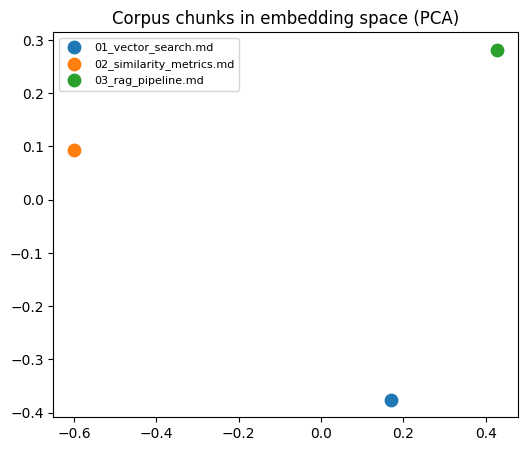

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

conn = get_connection()
cur = conn.cursor()
cur.execute("SELECT source, content, embedding FROM documents")
rows = cur.fetchall()
cur.close()
conn.close()

sources = [r[0] for r in rows]
vecs = np.array([r[2].to_list() for r in rows])

if len(vecs) >= 2:
    # svd_solver="full" -- the default "auto" solver picks randomized SVD once vecs has many
    # columns (1024), which is numerically unstable with only a handful of sample rows.
    n_components = min(2, len(vecs) - 1)
    coords = PCA(n_components=n_components, svd_solver="full").fit_transform(vecs)
    if n_components == 1:
        coords = np.column_stack([coords, np.zeros(len(coords))])
    fig, ax = plt.subplots(figsize=(6, 5))
    for src in sorted(set(sources)):
        mask = [s == src for s in sources]
        ax.scatter(coords[mask, 0], coords[mask, 1], label=src, s=80)
    ax.legend(fontsize=8)
    ax.set_title("Corpus chunks in embedding space (PCA)")
    plt.show()
else:
    print("Need at least 2 ingested chunks to plot. Run `python ingest.py` first.")

## 6. Chunking playground

Try different `chunk_size`/`overlap` values against a sample text and see how the split changes — see Q56/Q57 in `../docs/RAG_Knowledge_Base_Starter/08_Interview_Questions.md` for why this is the highest-leverage tuning knob in a RAG pipeline.

In [8]:
sample_text = open("sample_docs/03_rag_pipeline.md").read()

for size, overlap in [(30, 0), (30, 10), (60, 15)]:
    chunks = chunk_text(sample_text, chunk_size=size, overlap=overlap)
    print(f"chunk_size={size}, overlap={overlap} -> {len(chunks)} chunks")
    for i, c in enumerate(chunks):
        print(f"  [{i}] ({len(c.split())} words) {c[:70]}...")
    print()

chunk_size=30, overlap=0 -> 5 chunks
  [0] (30 words) # RAG Pipeline Retrieval-Augmented Generation grounds an LLM's answer ...
  [1] (30 words) answer questions about content it was never trained on. The pipeline h...
  [2] (30 words) plus the original text is stored in a vector database. Query time: the...
  [3] (30 words) and those chunks are inserted into the LLM's prompt as context before ...
  [4] (27 words) table running in Docker, and `rag.py` handles the query-time phase, ca...

chunk_size=30, overlap=10 -> 7 chunks
  [0] (30 words) # RAG Pipeline Retrieval-Augmented Generation grounds an LLM's answer ...
  [1] (30 words) memorized during training, which reduces hallucination and lets the mo...
  [2] (30 words) pipeline has two phases. Ingestion: documents are split into chunks, e...
  [3] (30 words) plus the original text is stored in a vector database. Query time: the...
  [4] (30 words) model, the vector database returns the top-K most similar chunks, and ...
  [5] (30 word